# Bird Model Analysis
This notebook look into correlations and properties of the bird model.

In [24]:
import inspect
from emachine_v2 import MatrixProductState
import Centraliser as cen
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D



plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = [10, 6]

print("=" * 70)
print("MODULE VALIDATION CHECK")
print("=" * 70)

# Check 1: TensorProductGroup exists and has key methods
print("\n[1] Checking Centraliser.TensorProductGroup...")
assert hasattr(cen, 'TensorProductGroup'), "TensorProductGroup class not found!"
tpg_methods = dir(cen.TensorProductGroup)
required_tpg_methods = ['find_symmetric_generators', 'find_generators_coefficients']
for method in required_tpg_methods:
    assert method in tpg_methods, f"TensorProductGroup missing method: {method}"
print("    ✓ TensorProductGroup class exists with required methods")

# Check 2: TensorProductGroupSO exists (new SO(N) framework)
print("\n[2] Checking Centraliser.TensorProductGroupSO (SO(N) framework)...")
assert hasattr(cen, 'TensorProductGroupSO'), "TensorProductGroupSO class not found!"
tpgo_methods = dir(cen.TensorProductGroupSO)
for method in required_tpg_methods:
    assert method in tpgo_methods, f"TensorProductGroupSO missing method: {method}"
print("    ✓ TensorProductGroupSO class exists with required methods")

# Check 3: SON class exists for SO(N) basis generation
print("\n[3] Checking Centraliser.SON (SO(N) basis)...")
assert hasattr(cen, 'SON'), "SON class not found!"
assert hasattr(cen.SON, 'so_basis'), "SON missing so_basis method!"
print("    ✓ SON class exists with so_basis method")

# Check 4: find_generators_coefficients signature includes new parameters
print("\n[4] Checking find_generators_coefficients parameters...")
sig = inspect.signature(cen.TensorProductGroup.find_generators_coefficients)
params = list(sig.parameters.keys())
required_params = ['self', 'M', 'basis_generators', 'verbose', 'reference_coeffs']
for param in required_params:
    assert param in params, f"find_generators_coefficients missing parameter: {param}"
print(f"    ✓ Parameters: {params}")

# Check 5: MatrixProductState wrapper method exists
print("\n[5] Checking MatrixProductState.find_generators_coefficients wrapper...")
mps_methods = dir(MatrixProductState)
assert 'find_generators_coefficients' in mps_methods, "MatrixProductState missing wrapper method!"
mps_sig = inspect.signature(MatrixProductState.find_generators_coefficients)
print(f"    ✓ Wrapper method exists with parameters: {list(mps_sig.parameters.keys())}")

MODULE VALIDATION CHECK

[1] Checking Centraliser.TensorProductGroup...
    ✓ TensorProductGroup class exists with required methods

[2] Checking Centraliser.TensorProductGroupSO (SO(N) framework)...
    ✓ TensorProductGroupSO class exists with required methods

[3] Checking Centraliser.SON (SO(N) basis)...
    ✓ SON class exists with so_basis method

[4] Checking find_generators_coefficients parameters...
    ✓ Parameters: ['self', 'M', 'verbose', 'basis_generators', 'reference_coeffs']

[5] Checking MatrixProductState.find_generators_coefficients wrapper...
    ✓ Wrapper method exists with parameters: ['self', 'M', 'basis', 'verbose', 'dim', 'reference_coeffs']


In [25]:
import importlib
import emachine_v2 as EM
from emachine_v2 import pprint, purify

importlib.reload(EM)

bd = EM.bird

## Form of the model
The site matrices are given by the form:

In [26]:
pprint(bd(0.6, 0.8).A)

[[[0.6325 0.    ]
  [0.     0.4472]]

 [[0.     0.7746]
  [0.8944 0.    ]]]


## Check Correlation Length
The system becomes memoryless when it approaches the line $p = q$, we can observe this with the plots below.

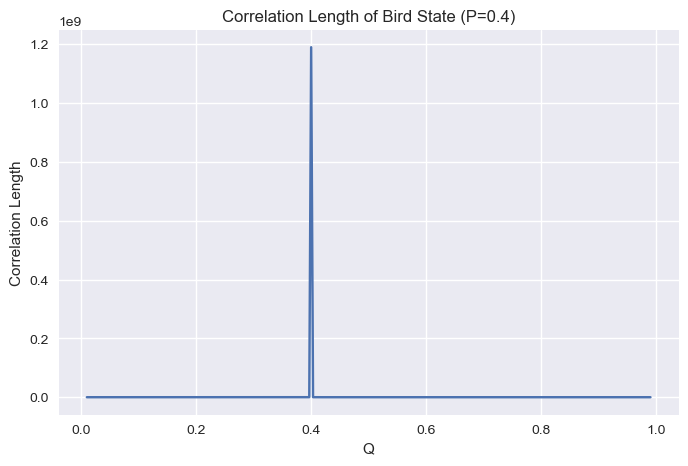

In [27]:
P = 0.4
Q = np.linspace(0.01,0.99, 300)

plt.figure(figsize=(8,5))
em = [bd(P,q) for q in Q]
corr = np.array([m.correlation_length() for m in em])

plt.plot(Q, corr)
plt.title(f"Correlation Length of Bird State (P={P})")
plt.xlabel("Q")
plt.ylabel("Correlation Length")
plt.show()


As we can see, the correlation length has a singularity when $p = q$.

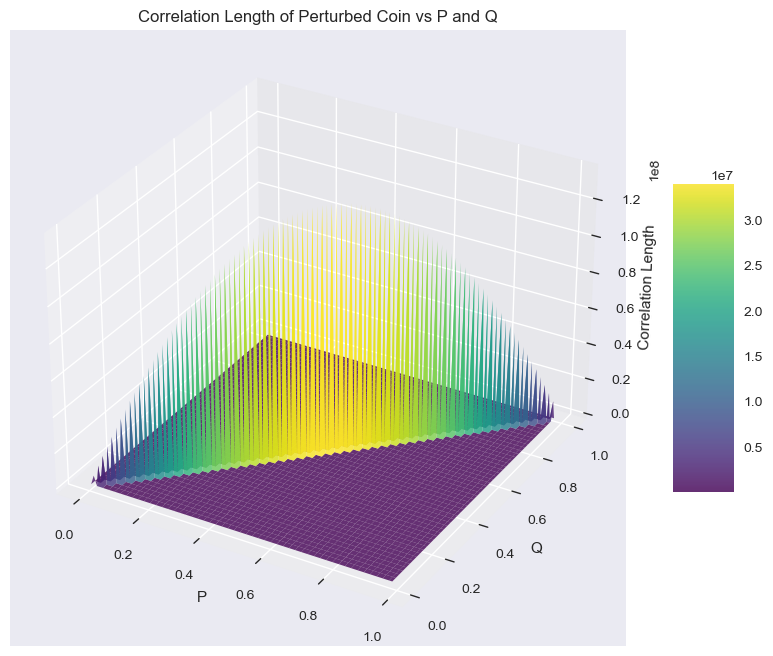

In [28]:
P_vals = np.linspace(0, 0.98, 100)
Q_vals = np.linspace(0.01, 0.99, 100)

# Create meshgrid for 3D plot
P_grid, Q_grid = np.meshgrid(P_vals, Q_vals)

# Compute correlation length for each (P, Q) pair
corr_grid = np.zeros_like(P_grid)
for i in range(len(P_vals)):
    for j in range(len(Q_vals)):
        corr_grid[j, i] = bd(P_vals[i], Q_vals[j]).correlation_length()

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(P_grid, Q_grid, corr_grid, cmap='viridis', alpha=0.8)

ax.set_xlabel('P')
ax.set_ylabel('Q')
ax.set_zlabel('Correlation Length')
ax.set_title('Correlation Length of Perturbed Coin vs P and Q')

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

The singularity is also shown here.

/opt/anaconda3/envs/physics_3_11_9/lib/python3.11/site-packages/scipy/linalg/_matfuncs.py:219: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)


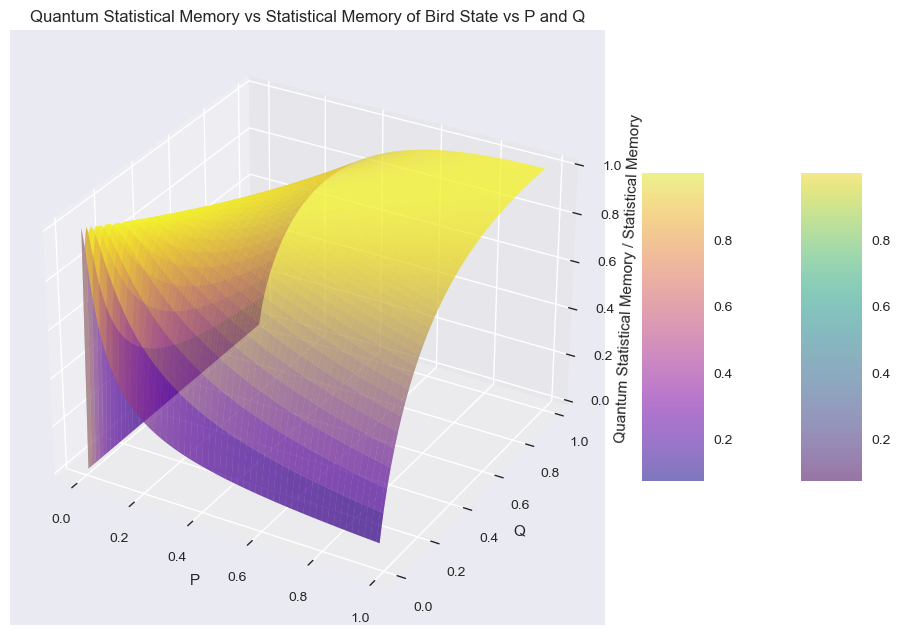

In [29]:
P_vals = np.linspace(0, 0.98, 100)
Q_vals = np.linspace(0.01, 0.99, 100)

# Create meshgrid for 3D plot
P_grid, Q_grid = np.meshgrid(P_vals, Q_vals)

# Compute quantum statistical memory for each (P, Q) pair
qsm_grid = np.zeros_like(P_grid)
for i in range(len(P_vals)):
    for j in range(len(Q_vals)):
        qsm_grid[j, i] = bd(P_vals[i], Q_vals[j]).quantum_statistical_memory()

sm_grid = np.zeros_like(P_grid)
for i in range(len(P_vals)):
    for j in range(len(Q_vals)):
        sm_grid[j, i] = bd(P_vals[i], Q_vals[j]).statistical_memory()

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(P_grid, Q_grid, qsm_grid, cmap='viridis', alpha=0.5)

surf2 = ax.plot_surface(P_grid, Q_grid, sm_grid, cmap='plasma', alpha=0.5)

ax.set_xlabel('P')
ax.set_ylabel('Q')
ax.set_zlabel('Quantum Statistical Memory / Statistical Memory')
ax.set_title('Quantum Statistical Memory vs Statistical Memory of Bird State vs P and Q')

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
fig.colorbar(surf2, ax=ax, shrink=0.5, aspect=5)

plt.show()

Interestingly enough, the classical and quantum staistical memory overlaps with each other, hinting toward that there are no quantum advantage in modelling this system in the quantum manner??

## Correlation Function in the Bird Model
This section attempts to find the correlation behaviours of the Bird model with different operators.

### Pauli $\sigma_z$ Correlation Analysis

Analysis of correlation functions using the Pauli Z observable
$$
\sigma_z = \begin{bmatrix}1 & 0 \\\\ 0 & -1\end{bmatrix}.
$$

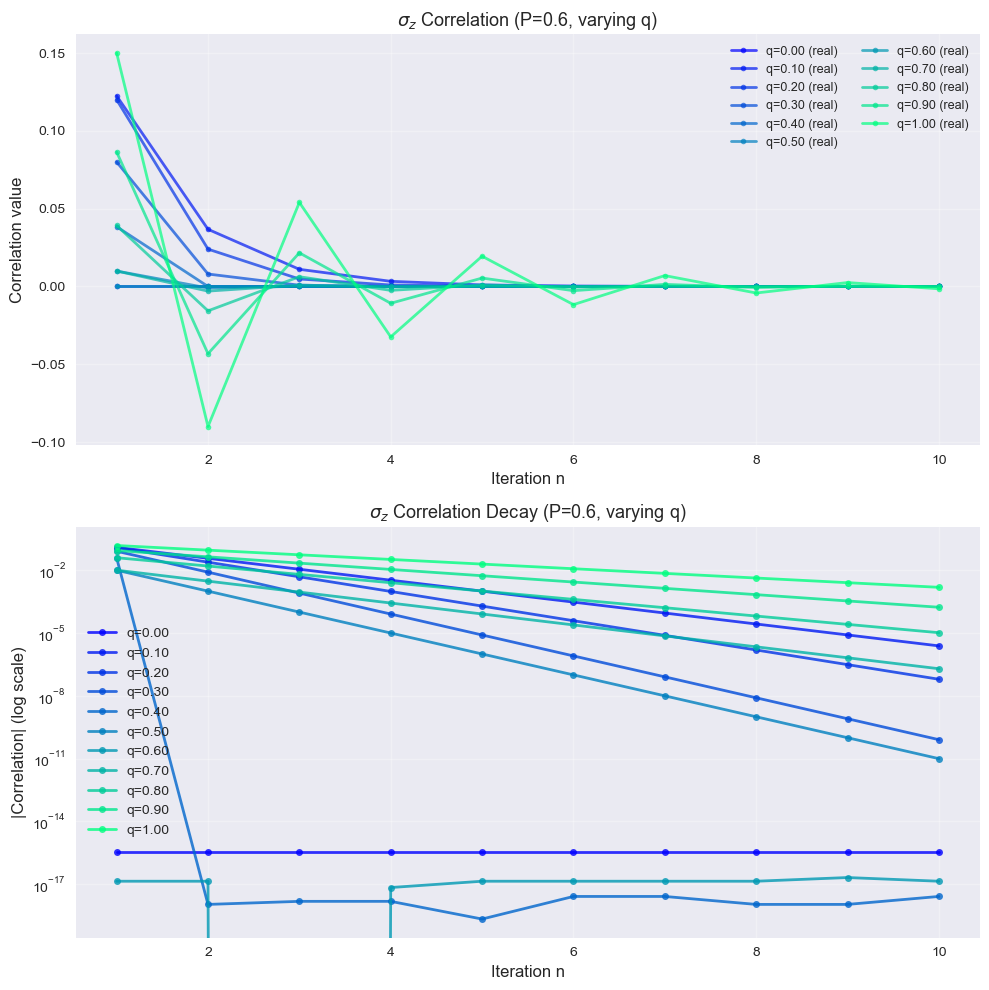

$\sigma_z$ Correlation Analysis with w_bird (fixed P=0.6, varying q)
q values tested: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [38]:
# Define Pauli σ_z observable
sigma_z = np.array([[1, 0], [0, -1]])

# Set up parameters
P = 0.6  # Fixed parameter
q_values = np.linspace(0,1,11)  # Varying parameter
n = np.arange(1, 11)

# Create color map for different q values
colors = plt.cm.winter(np.linspace(0, 1, len(q_values)))

# Create figure with two subplots (vertical layout)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot for each q value on the same graph
for idx, (q, color) in enumerate(zip(q_values, colors)):
    # Create bird EMachine with parameters (P, q)
    em_bird = bd(P, q)
    
    # Compute correlations using σ_z
    corr_bird_z = np.array([em_bird.correlation(sigma_z, k) for k in n])
    
    # Plot 1 (top): Real part and absolute value overlaid
    axes[0].plot(n, np.real(corr_bird_z), 'o-', color=color, linewidth=2, 
                 markersize=4, label=f'q={q:.2f} (real)', alpha=0.7)
    #axes[0].plot(n, np.abs(corr_bird_z), 's--', color=color, linewidth=2, 
    #             markersize=4, label=f'q={q:.2f} (|corr|)', alpha=0.7)
    
    # Plot 2 (bottom): Log scale
    axes[1].semilogy(n, np.abs(corr_bird_z), 'o-', color=color, linewidth=2, 
                     markersize=5, label=f'q={q:.2f}', alpha=0.8)

# Configure top plot
axes[0].set_xlabel('Iteration n', fontsize=12)
axes[0].set_ylabel('Correlation value', fontsize=12)
axes[0].set_title(rf'$\sigma_z$ Correlation (P={P}, varying q)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, loc='best', ncol=2)

# Configure bottom plot
axes[1].set_xlabel('Iteration n', fontsize=12)
axes[1].set_ylabel('|Correlation| (log scale)', fontsize=12)
axes[1].set_title(rf'$\sigma_z$ Correlation Decay (P={P}, varying q)', fontsize=13)
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(rf"$\sigma_z$ Correlation Analysis with w_bird (fixed P={P}, varying q)")
print(f"q values tested: {q_values}")


### Isolating the Weird Cases

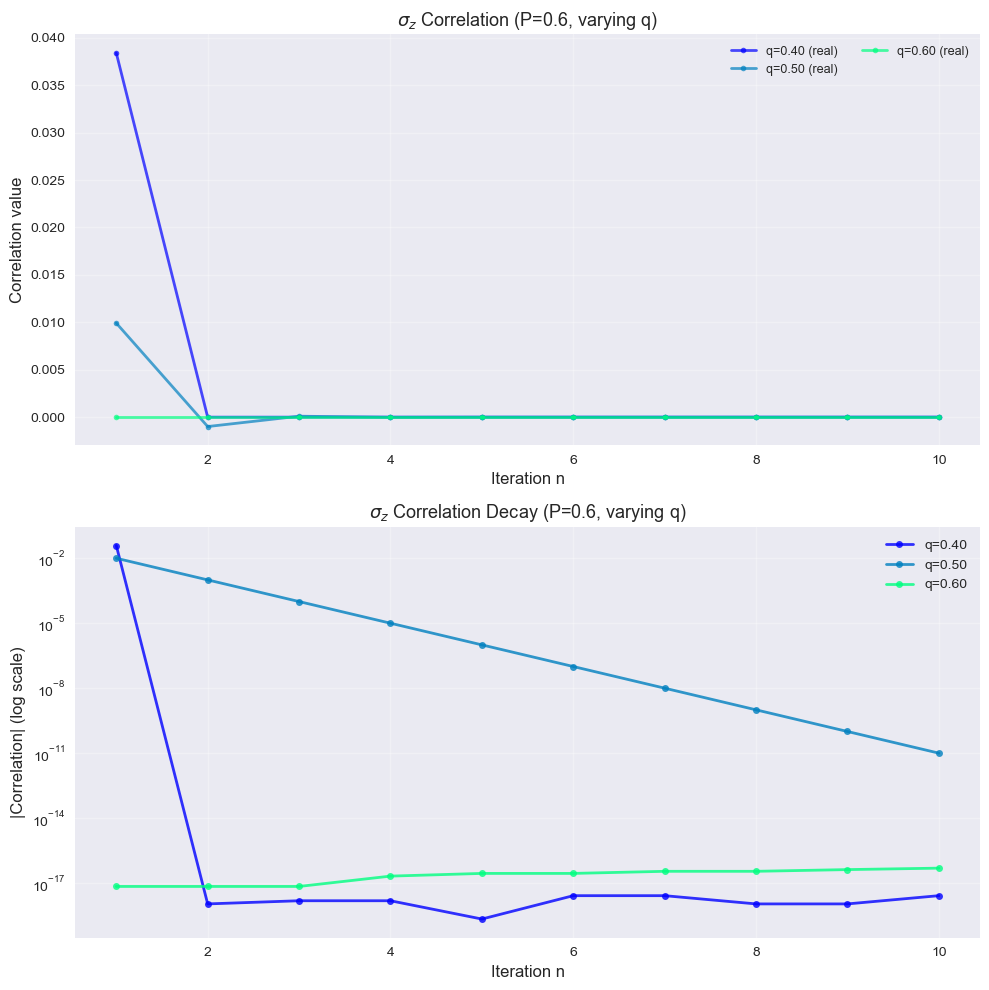

$\sigma_z$ Correlation Analysis with w_bird (fixed P=0.6, varying q)
q values tested: [0.4, 0.5, 0.6]


In [39]:
# Define Pauli σ_z observable
sigma_z = np.array([[1, 0], [0, -1]])

# Set up parameters
P = 0.6  # Fixed parameter
q_values = [0.4, 0.5, 0.6]  # Varying parameter
n = np.arange(1, 11)

# Create color map for different q values
colors = plt.cm.winter(np.linspace(0, 1, len(q_values)))

# Create figure with two subplots (vertical layout)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot for each q value on the same graph
for idx, (q, color) in enumerate(zip(q_values, colors)):
    # Create bird EMachine with parameters (P, q)
    em_bird = bd(P, q)
    
    # Compute correlations using σ_z
    corr_bird_z = np.array([em_bird.correlation(sigma_z, k) for k in n])
    
    # Plot 1 (top): Real part and absolute value overlaid
    axes[0].plot(n, np.real(corr_bird_z), 'o-', color=color, linewidth=2, 
                 markersize=4, label=f'q={q:.2f} (real)', alpha=0.7)
    #axes[0].plot(n, np.abs(corr_bird_z), 's--', color=color, linewidth=2, 
    #             markersize=4, label=f'q={q:.2f} (|corr|)', alpha=0.7)
    
    # Plot 2 (bottom): Log scale
    axes[1].semilogy(n, np.abs(corr_bird_z), 'o-', color=color, linewidth=2, 
                     markersize=5, label=f'q={q:.2f}', alpha=0.8)

# Configure top plot
axes[0].set_xlabel('Iteration n', fontsize=12)
axes[0].set_ylabel('Correlation value', fontsize=12)
axes[0].set_title(rf'$\sigma_z$ Correlation (P={P}, varying q)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, loc='best', ncol=2)

# Configure bottom plot
axes[1].set_xlabel('Iteration n', fontsize=12)
axes[1].set_ylabel('|Correlation| (log scale)', fontsize=12)
axes[1].set_title(rf'$\sigma_z$ Correlation Decay (P={P}, varying q)', fontsize=13)
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(rf"$\sigma_z$ Correlation Analysis with w_bird (fixed P={P}, varying q)")
print(f"q values tested: {q_values}")


As we can see, though for the $q=0.4$ doesn't seem that much like a singularity, its correlation in the z-basis drops extremely quickly. This probably have to do with the form of the correlation function when spectral decomposed (Ref. to my paper lol). Everything just seems to go back to normal for $q=0.5$, and $q=0.6$ is just dead.

### Pauli $\sigma_x$ Correlation Analysis

Analysis of correlation functions using the Pauli X observable
$$
\sigma_x = \begin{bmatrix}0 & 1 \\\\ 1 & 0\end{bmatrix}.
$$

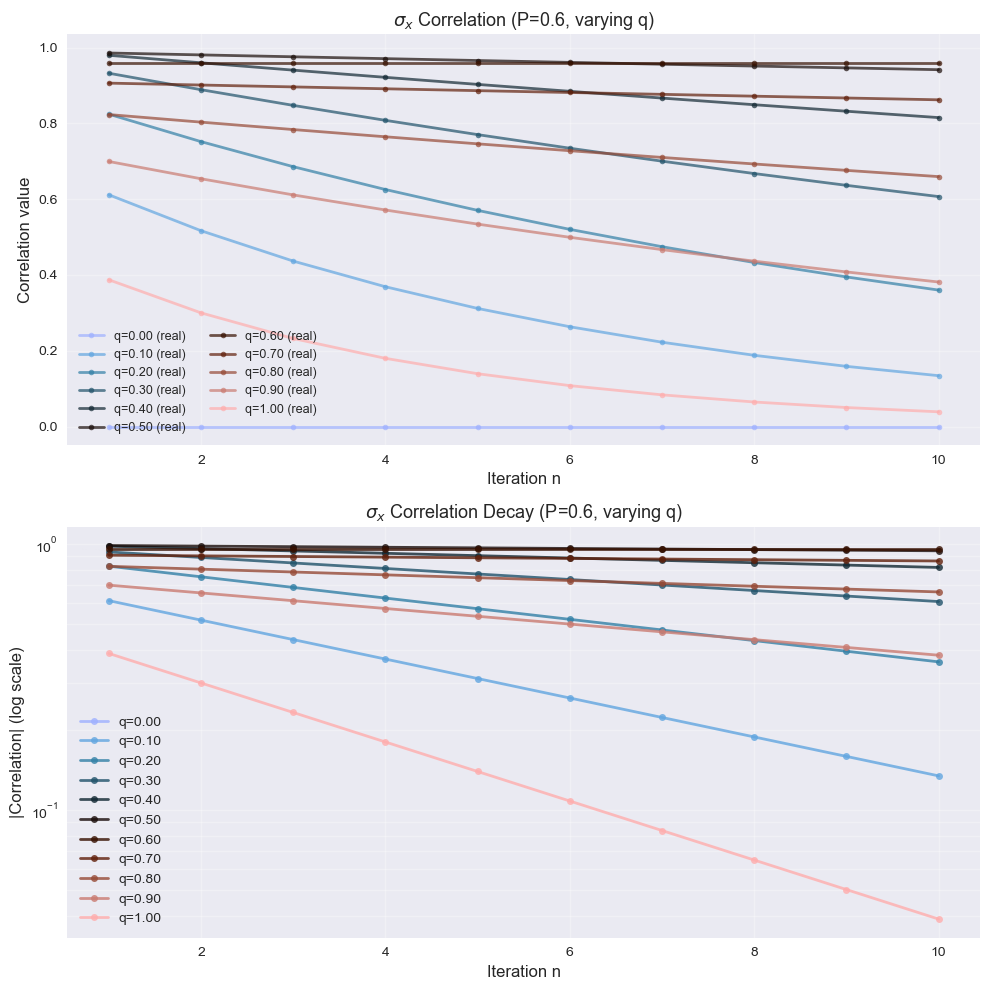

$\sigma_x$ Correlation Analysis with w_bird (fixed P=0.6, varying q)
q values tested: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [36]:
# Define Pauli σ_x observable
sigma_x = np.array([[0, 1], [1, 0]])

# Set up parameters (same as σ_z analysis)
P = 0.6  # Fixed parameter
q_values = np.linspace(0, 1, 11)  # Varying parameter
n = np.arange(1, 11)

# Create color map for different q values
colors = plt.cm.berlin(np.linspace(0, 1, len(q_values)))

# Create figure with two subplots (vertical layout)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot for each q value on the same graph
for idx, (q, color) in enumerate(zip(q_values, colors)):
    # Create bird EMachine with parameters (P, q)
    em_bird = bd(P, q)
    
    # Compute correlations using σ_x
    corr_bird_x = np.array([em_bird.correlation(sigma_x, k) for k in n])
    
    # Plot 1 (top): Real part and absolute value overlaid
    axes[0].plot(n, np.real(corr_bird_x), 'o-', color=color, linewidth=2, 
                 markersize=4, label=f'q={q:.2f} (real)', alpha=0.7)
    
    # Plot 2 (bottom): Log scale
    axes[1].semilogy(n, np.abs(corr_bird_x), 'o-', color=color, linewidth=2, 
                     markersize=5, label=f'q={q:.2f}', alpha=0.8)

# Configure top plot
axes[0].set_xlabel('Iteration n', fontsize=12)
axes[0].set_ylabel('Correlation value', fontsize=12)
axes[0].set_title(rf'$\sigma_x$ Correlation (P={P}, varying q)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, loc='best', ncol=2)

# Configure bottom plot
axes[1].set_xlabel('Iteration n', fontsize=12)
axes[1].set_ylabel('|Correlation| (log scale)', fontsize=12)
axes[1].set_title(rf'$\sigma_x$ Correlation Decay (P={P}, varying q)', fontsize=13)
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(rf"$\sigma_x$ Correlation Analysis with w_bird (fixed P={P}, varying q)")
print(f"q values tested: {q_values}")

Again isolating cases around singularity.

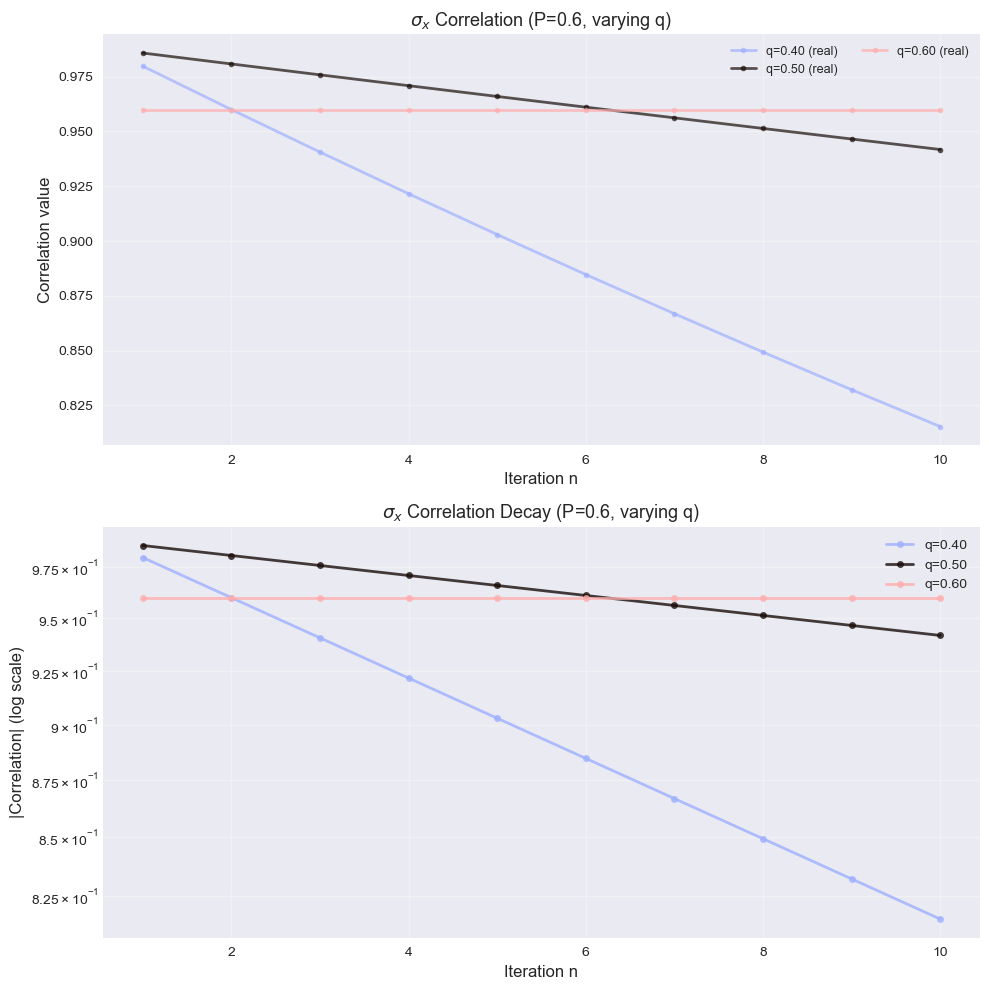

$\sigma_x$ Correlation Analysis with w_bird (fixed P=0.6, varying q)
q values tested: [0.4, 0.5, 0.6]


In [ ]:
# Define Pauli σ_x observable
sigma_x = np.array([[0, 1], [1, 0]])

# Set up parameters (same as σ_z analysis)
P = 0.6  # Fixed parameter
q_values = [0.4, 0.5, 0.6]  # Varying parameter
n = np.arange(1, 11)

# Create color map for different q values
colors = plt.cm.berlin(np.linspace(0, 1, len(q_values)))

# Create figure with two subplots (vertical layout)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot for each q value on the same graph
for idx, (q, color) in enumerate(zip(q_values, colors)):
    # Create bird EMachine with parameters (P, q)
    em_bird = bd(P, q)
    
    # Compute correlations using σ_x
    corr_bird_x = np.array([em_bird.correlation(sigma_x, k) for k in n])
    
    # Plot 1 (top): Real part and absolute value overlaid
    axes[0].plot(n, np.real(corr_bird_x), 'o-', color=color, linewidth=2, 
                 markersize=4, label=f'q={q:.2f} (real)', alpha=0.7)
    
    # Plot 2 (bottom): Log scale
    axes[1].semilogy(n, np.abs(corr_bird_x), 'o-', color=color, linewidth=2, 
                     markersize=5, label=f'q={q:.2f}', alpha=0.8)

# Configure top plot
axes[0].set_xlabel('Iteration n', fontsize=12)
axes[0].set_ylabel('Correlation value', fontsize=12)
axes[0].set_title(rf'$\sigma_x$ Correlation (P={P}, varying q)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, loc='best', ncol=2)

# Configure bottom plot
axes[1].set_xlabel('Iteration n', fontsize=12)
axes[1].set_ylabel('|Correlation| (log scale)', fontsize=12)
axes[1].set_title(rf'$\sigma_x$ Correlation Decay (P={P}, varying q)', fontsize=13)
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(rf"$\sigma_x$ Correlation Analysis with bird (fixed P={P}, varying q)")
print(f"q values tested: {q_values}")

The behaviour in the x-basis looks much nicer, where we can see that there are no weird behaviour at $q=0.4$ in this case, where instead of having no correlation as in z-basis, the correltaion in the x-basis when $q=0.6$ persists forever and remains constant. 

### Asymptotic Variance Analysis (Bird process)

Analysis of asymptotic variance across varying Q parameter with fixed P for the w_bird process.

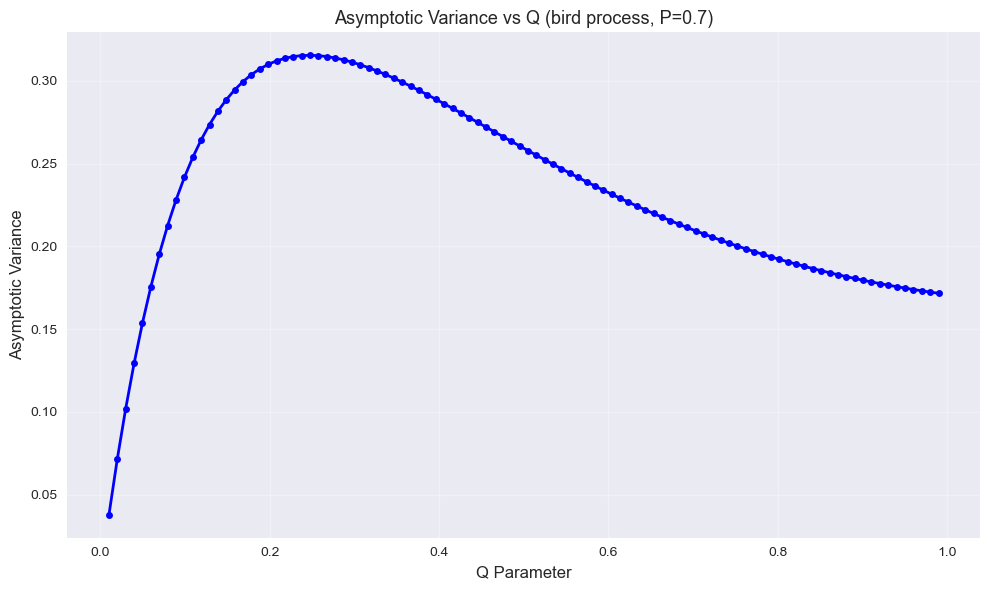

Asymptotic variance analysis for bird(P=0.7, Q)
Q range: 0.01 to 0.99
Variance range: 0.0380 to 0.3154


In [37]:
# Asymptotic variance analysis for bird process
# Fix P, vary Q - using built-in asymptotic_variance method

# Fix P parameter
P_fixed = 0.7
Q_values = np.linspace(0.01, 0.99, 100)  # Vary Q across this range

# Define the discrete function for asymptotic variance
# This is a function that maps state indices to values
# For a binary system, we have 2 states
# Use [0, 1] to compute variance on the second state
f_func = np.array([1, 0])

em = np.array([bd(P_fixed, q) for q in Q_values])
asym_var = np.array([m.asymptotic_variance(f_func) for m in em])
plt.figure(figsize=(10, 6))
plt.plot(Q_values, asym_var, 'bo-', linewidth=2, markersize=5)
plt.xlabel('Q Parameter', fontsize=12)
plt.ylabel('Asymptotic Variance', fontsize=12)
plt.title(rf'Asymptotic Variance vs Q (bird process, P={P_fixed})', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(rf'Asymptotic variance analysis for bird(P={P_fixed}, Q)')
print(rf"Q range: {Q_values[0]:.2f} to {Q_values[-1]:.2f}")
print(rf"Variance range: {np.nanmin(asym_var):.4f} to {np.nanmax(asym_var):.4f}")

## Symmetry Finding for the Bird

We now attempt to find the symmetry group generators for the perturbed coin process for a fixed value of $p \neq q$.

In [ ]:
Q = 0.6
ph_3_3 = bd(P, Q).parent_hamiltonian(3, 3)

print("The parent hamiltonian in consideration is:")
pprint(ph_3_3)
gen = [*bd(P, Q).sun_symmetry(ph_3_3, return_coeff = False)]

The parent hamiltonian in consideration is:
[[ 0.2449  0.      0.     -0.2499  0.      0.2449 -0.2499  0.    ]
 [ 0.      0.2449 -0.2499  0.      0.2449  0.      0.     -0.2499]
 [ 0.     -0.2499  0.7551  0.     -0.2499  0.      0.     -0.2449]
 [-0.2499  0.      0.      0.7551  0.     -0.2499 -0.2449  0.    ]
 [ 0.      0.2449 -0.2499  0.      0.2449  0.      0.     -0.2499]
 [ 0.2449  0.      0.     -0.2499  0.      0.2449 -0.2499  0.    ]
 [-0.2499  0.      0.     -0.2449  0.     -0.2499  0.7551  0.    ]
 [ 0.     -0.2499 -0.2449  0.     -0.2499  0.      0.      0.7551]]

SYMMETRIC GENERATORS ANALYSIS

⚠️  No symmetry found: The null space is empty.



Now for the case $p = q = 0.5$,

In [ ]:
P = 0.499999
Q = 0.5
ph_3_3 = bd(P, Q).parent_hamiltonian(3, 3)

print("The parent hamiltonian in consideration is:")
pprint(ph_3_3)
print("Verifying that the MPS is in the ground space of the parent hamiltonian:")
print("ph_3_3 @ state = ", purify(ph_3_3 @ bd(P, Q).to_ground_space(3,np.array([[1,2],[3,4]]))))
gen = [*bd(P, Q).sun_symmetry(purify(ph_3_3), return_coeff = False)]


The parent hamiltonian in consideration is:
[[ 0.25  0.    0.   -0.25  0.    0.25 -0.25  0.  ]
 [ 0.    0.25 -0.25  0.    0.25  0.    0.   -0.25]
 [ 0.   -0.25  0.75  0.   -0.25  0.    0.   -0.25]
 [-0.25  0.    0.    0.75  0.   -0.25 -0.25  0.  ]
 [ 0.    0.25 -0.25  0.    0.25  0.    0.   -0.25]
 [ 0.25  0.    0.   -0.25  0.    0.25 -0.25  0.  ]
 [-0.25  0.    0.   -0.25  0.   -0.25  0.75  0.  ]
 [ 0.   -0.25 -0.25  0.   -0.25  0.    0.    0.75]]
Verifying that the MPS is in the ground space of the parent hamiltonian:
ph_3_3 @ state =  [0. 0. 0. 0. 0. 0. 0. 0.]

SYMMETRIC GENERATORS ANALYSIS

⚠️  No symmetry found: The null space is empty.



Clearly there are no physical symmetry of the parent hamiltoniannfor this model.